In [ ]:
# Imports — 2-channel / 9-state stack (protocols_2ch / daq.NICardOutDual /
# experiment.run_session_2ch), replacing the old single-channel NICardOut /
# run_session flow used earlier in this notebook.

from camera import BaslerCamera
from daq import NICardOutDual, NICardIn, read_stage_voltage, read_ai_channel
from function_gen import FunctionGenerator
from protocols_2ch import SessionParams2Ch, V_CENTER
from experiment import (
    preview_particle, calibrate_trap_center, ensure_stage_at,
    run_session_2ch, run_batch_2ch, plot_session_2ch,
    build_datasync, save_session,
)
from analysis import (
    compute_potential, plot_potential,
    extract_protocol_events, lambda_trap_nm_for_state,
    compute_cumulative_work_kT, plot_x_lambda_grid, plot_work_grid, export_for_matlab,
    discover_session_files, load_session_files,
    extract_protocol_events_from_folder, extract_protocol_events_from_folders,
    extract_protocol_stage_events_from_folder, plot_stage_vs_protocol_grid,
    compute_work_split_kT, plot_trap_relative_grid, plot_work_split_grid,
    compute_trigger_energy_reference_kT,
    compute_experimental_probabilities, compute_weighted_mean_work_kT,
    compute_weighted_average_kT, load_combined_calib_pos_px,
)
from helper import *
import numpy as np
import matplotlib.pyplot as plt
import time


In [46]:
import importlib
import analysis
importlib.reload(analysis)
from analysis import (
    compute_potential, plot_potential,
    extract_protocol_events, lambda_trap_nm_for_state,
    compute_cumulative_work_kT, plot_x_lambda_grid, plot_work_grid, export_for_matlab,
    discover_session_files, load_session_files,
    extract_protocol_events_from_folder, extract_protocol_events_from_folders,
    extract_protocol_stage_events_from_folder, plot_stage_vs_protocol_grid,
    compute_work_split_kT, plot_trap_relative_grid, plot_work_split_grid,
    compute_trigger_energy_reference_kT,
    compute_experimental_probabilities, compute_weighted_mean_work_kT,
    compute_weighted_average_kT, load_combined_calib_pos_px
)


## 1. Open camera, set ROI/exposure/gamma

Reuses the ROI/exposure/gamma already validated earlier in this notebook.

In [2]:
exposure_us=700.0
Cam = BaslerCamera(exposure_us=exposure_us)
Cam.roi(800, 350, 250, 250)
Cam.gamma(3)


[Camera] Exposure = 700.0
[Camera] Opened
[Camera] ROI  252x250  offset (800,350)  [requested 250x250 @ (800,350)]
[Camera] Gamma = 3


In [5]:
Cam.exposure(700)
Cam.startview()

[Camera] Exposure = 700
[Camera] Preview started (particle_cross=False)


In [6]:
Cam.stopview()

[Camera] Preview stopped


In [ ]:
Cam.roi(700, 380, 400, 200)


Confirm the particle is actually visible before doing anything else — live preview at 100 fps, self-paced (press Enter in the console when you've seen it).

In [20]:
preview_particle(Cam, fps=100.0)


[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Preview started (particle_cross=True)
[Camera] Preview stopped


## 2. Open the DAQ + function generator, move the stage to 5V

`ensure_stage_at` only ramps (slowly, 10 nm/s) and waits (300s settle) if the stage isn't already at 5V — no needless wait if it's already parked there.

In [4]:
PROTOCOL_DT_S = 3.0
AO_RATE       = 1000
AI_RATE       = 3000

# AOM (laser power) voltages - see set_dc_level() and ensure_stage_at()'s
# aom_* params. TRANSIT = strong trap during physical stage moves (don't
# lose the particle in transit); EXPERIMENT = whatever's right for actual
# measurements - fill in your real value below.
AOM_TRANSIT_V    = 2.0     # near-max, used only while the stage is moving
AOM_EXPERIMENT_V = 0.9     # TODO: set to your real experiment AOM level

# Close any ao/ai/funcgen/aom_gen already open from a previous run of this
# cell before creating new ones - otherwise the old NICardOutDual's two
# nidaqmx Tasks (AO + DO) never get closed, and Python garbage-collecting
# them later prints a DaqResourceWarning ("Task ... was not explicitly
# closed") - or worse, a real "device busy" error if you reopen the same
# channels before the old ones are released.
for _name in ("ao", "ai", "funcgen", "aom_gen"):
    if _name in globals():
        try:
            globals()[_name].close()
        except Exception:
            pass

ao      = NICardOutDual(n_samples=int(PROTOCOL_DT_S * AO_RATE), rate=AO_RATE)
ai      = NICardIn(rate=AI_RATE)
funcgen = FunctionGenerator()   # camera-trigger generator 
aom_gen = FunctionGenerator(usb_id="USB0::0x0699::0x0358::C020332::INSTR")  # AOM/laser-power generator 

Cam.hardwareTrigg()
#ensure_stage_at(ao, V_CENTER, speed_nm_per_s=200.0, camera=Cam, live_preview=True, settle_s = 0.5)


[Camera] Hardware trigger (Line2, rising edge)


In [17]:
AOM_EXPERIMENT_V = 1
aom_gen.set_dc_level(AOM_EXPERIMENT_V)

In [6]:
ensure_stage_at(ao, V_CENTER, speed_nm_per_s=20.0, camera=Cam, live_preview=True, settle_s = 300,
                aom_gen=aom_gen, aom_transit_v=AOM_TRANSIT_V, aom_experiment_v=AOM_EXPERIMENT_V)


Setting AOM to 2.000 V for the transit ...
[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Preview started (particle_cross=True)
Stage at 6.995 V, ramping to 5.000 V at 20.0 nm/s ...
Arrived at 5.000 V.
Waiting 10s, then setting AOM to 0.900 V ...
Settling for 300s ...
  ... 270s remaining
  ... 240s remaining
  ... 210s remaining
  ... 180s remaining
  ... 150s remaining
  ... 120s remaining
  ... 90s remaining
  ... 60s remaining
  ... 30s remaining
  ... 0s remaining
Settle complete.
[Camera] Preview stopped


5.0

In [19]:
v_adder  = read_ai_channel("AdderOut")   # ai3 — commanded ao0/10+ao1
v_stage  = read_ai_channel("Stage")      # ai1 — same as read_stage_voltage()
v_camout = read_ai_channel("CamOut")     # ai2 — camera trigger confirmation line
v_aom    = read_ai_channel("AOM")        # ai0

print("v_adder  = ", v_adder)
print("v_stage  = ", v_stage)

v_adder  =  4.997664764524671
v_stage  =  4.979730602035707


In [ ]:
ao.set_dc(ao0_v=0, ao1_v=0)


## 3. Calibrate the trap center

Run once (or whenever you want to recheck) with the particle resting undisturbed. The camera stays open afterward — unlike the earlier exploratory cells in this notebook, we need it for everything below.

In [21]:
import os
CALIB_FOLDER = r"D:\Data\Aug_26\26-08_Testing_Full_Engine\calib05"   # folder to hold this batch's calibration runs
N_CALIB      = 3                    # how many calibrate_trap_center() runs
os.makedirs(CALIB_FOLDER, exist_ok=True)

calib_runs = []   # [(x_center_nm, y_center_nm, calib_pos_px), ...] - every run, in memory too
for i in range(1, N_CALIB + 1):
    x_center_nm, y_center_nm, calib_pos_px = calibrate_trap_center(
        Cam, duration_s=3600.0, fps=100.0,
        savepath=os.path.join(CALIB_FOLDER, f"calib{i}"),   # -> CALIB_FOLDER/calib{i}_calib_pos_px.npy
    )
    print(f"Run {i}/{N_CALIB}: x_center_nm={x_center_nm:+.1f} nm  y_center_nm={y_center_nm:+.1f} nm")
    calib_runs.append((x_center_nm, y_center_nm, calib_pos_px))

# x_center_nm/y_center_nm above are the LAST run's values (still feed the
# pinning cell right below unchanged) - calib_runs holds every run's own
# (x_center_nm, y_center_nm, calib_pos_px) if you want to compare/average
# across the N runs before picking what to pin.
#
# calib_pos_px columns: [x_px, y_px, time_s] — one row per frame, NaN where
# a frame was dropped or the particle wasn't found. Multiply calib_pos_px[:, :2]
# by your own nm_per_px if/when you want it in nm instead of pixels.


[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Started
[Camera] Stopped
Trap center: x=+1796.0 nm  y=+1894.9 nm  (360000/360000 frames had a valid reading)
Saved: D:\Data\Aug_26\26-08_Testing_Full_Engine\calib05\calib1_calib_pos_px.npy
Run 1/3: x_center_nm=+1796.0 nm  y_center_nm=+1894.9 nm
[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Started
[Camera] Stopped
Trap center: x=+1788.7 nm  y=+1892.3 nm  (360000/360000 frames had a valid reading)
Saved: D:\Data\Aug_26\26-08_Testing_Full_Engine\calib05\calib2_calib_pos_px.npy
Run 2/3: x_center_nm=+1788.7 nm  y_center_nm=+1892.3 nm
[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Started
[Camera] Stopped
Trap center: x=+1794.1 nm  y=+1893.8 nm  (360000/360000 frames had a valid reading)
Saved: D:\Data\Aug_26\26-08_Testing_Full_Engine\calib05\calib3_calib_pos_px.npy
Run 3/3: x_center_nm=+1794.1 nm  y_center_nm=+1893.8 nm


In [22]:
CALIB_FOLDER = r"D:\Data\Aug_26\26-08_Testing_Full_Engine\calib05"

In [42]:
from camera import NM_PER_PX

combined_calib_px = load_combined_calib_pos_px(CALIB_FOLDER)   # every *_calib_pos_px.npy in CALIB_FOLDER, pooled
valid = ~np.isnan(combined_calib_px[:, 0])
x_center_nm = float(np.mean(combined_calib_px[valid, 0])) * NM_PER_PX
y_center_nm = float(np.mean(combined_calib_px[valid, 1])) * NM_PER_PX
print(f"Combined trap center over {valid.sum()}/{len(combined_calib_px)} valid frames "
      f"(pooled across every calib run saved in {CALIB_FOLDER}):")
print(f"  x_center_nm = {x_center_nm:+.2f} nm   y_center_nm = {y_center_nm:+.2f} nm")

# To pin a hand-picked value instead of the combined-file estimate above,
# just reassign below, e.g.:
# x_center_nm = 1594.38
# y_center_nm = 2086


Combined trap center over 1080000/1080000 valid frames (pooled across every calib run saved in D:\Data\Aug_26\26-08_Testing_Full_Engine\calib05):
  x_center_nm = +1792.93 nm   y_center_nm = +1893.67 nm


In [49]:
x_center_nm = 1792.93 
y_center_nm = 1893.67

0/360000 frames dropped or not found (0.0%)


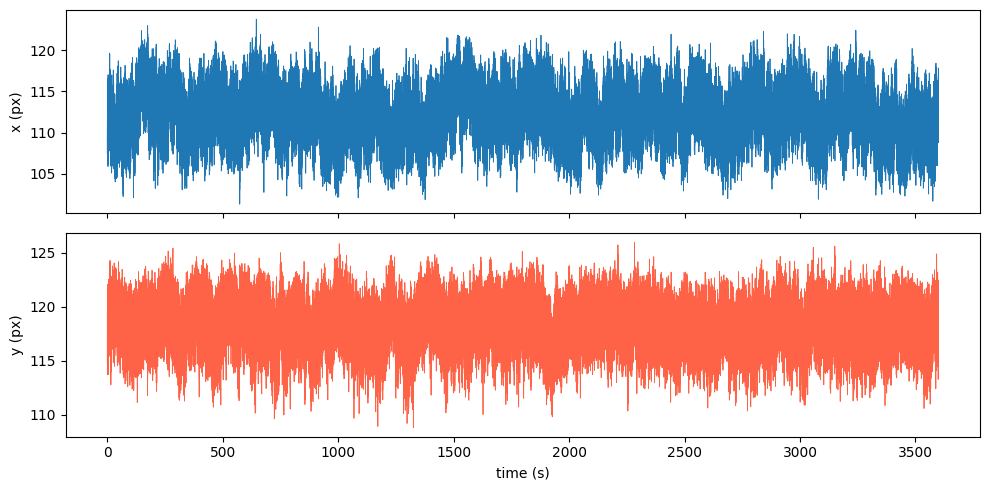

In [30]:
# Quick look at tracking quality — raw pixels, not nm — gaps = dropped
# frames or lost particle.
n_dropped = int(np.isnan(calib_pos_px[:, 0]).sum())
print(f"{n_dropped}/{len(calib_pos_px)} frames dropped or not found "
      f"({n_dropped/len(calib_pos_px):.1%})")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(calib_pos_px[:, 2], calib_pos_px[:, 0], lw=0.6)
axes[0].set_ylabel("x (px)")
axes[1].plot(calib_pos_px[:, 2], calib_pos_px[:, 1], lw=0.6, color="tomato")
axes[1].set_ylabel("y (px)")
axes[1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()


k_fit = 2.1671e-06 N/m   k_eq = 2.0225e-06 N/m   (T = 298 K)


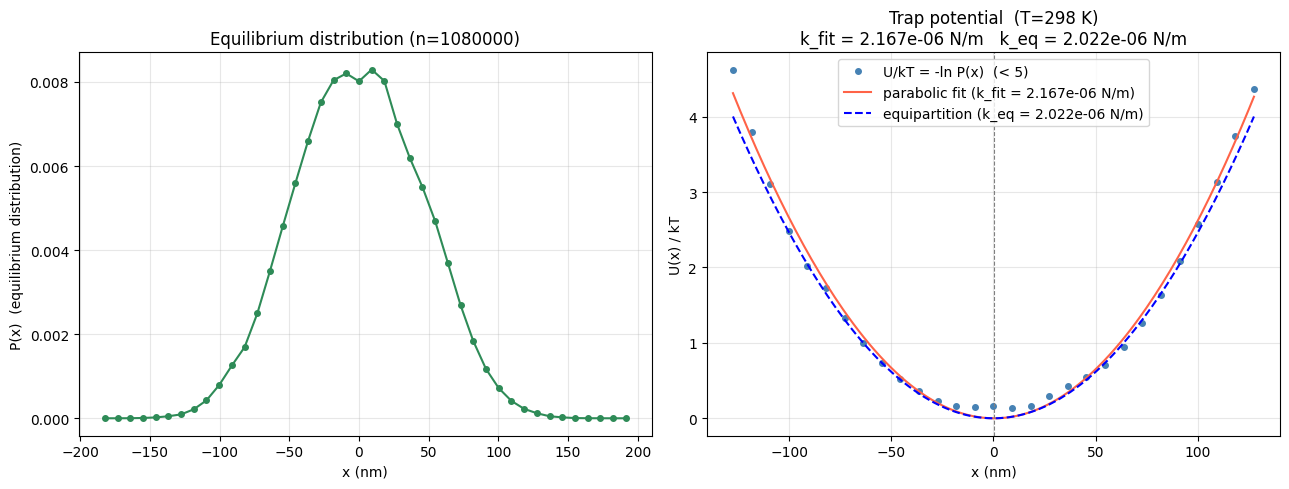

In [50]:
from camera import NM_PER_PX

# Uses the SAME combined, pooled data (combined_calib_px, from the cell
# above) for both x_center_nm and the potential itself - previously this
# mixed calib_pos_px (only the LAST calibrate_trap_center() run still in
# memory) with whatever x_center_nm happened to be pinned, which didn't
# have to come from the same data at all.
x_nm_equilibrium = combined_calib_px[:, 0] * NM_PER_PX - x_center_nm

potential_result = compute_potential(x_nm_equilibrium, n_bins=41, T_K=298.0)
print(f"k_fit = {potential_result['k_fit_N_per_m']:.4e} N/m   "
      f"k_eq = {potential_result['k_eq_N_per_m']:.4e} N/m   "
      f"(T = {potential_result['T_K']:.0f} K)")

plot_potential(potential_result)


## 3b. Analytical-protocol-consistent decode threshold

`xth_nm` must match whatever `x_thresh_sigma_multiple`/`kappa`/`T` the
saved analytical protocol files (section 3c) were actually computed
with — using the same formula `sdesim.params.SystemVariables.create()`
uses (`x_thresh = sqrt(k_B*T/kappa) * x_thresh_sigma_multiple`, confirmed
directly against that source), reproduced here rather than imported since
`analytical_optimal_protocol_computation` lives in its own venv
(scipy/numba) — see `analytical_protocols.py`'s docstring. Fill in the
three constants below to match your actual run; everywhere downstream
(sections 4, 5, 6) uses this same `xth_nm`, not an independent guess.

Also computes `xth_nm_single`, the same formula for the single-measurement
(`delta_t_s=0`) case — its own constants, since the `t2_0_...` files (section
3c) were generated with a different `x_thresh_sigma_multiple`/`kappa` than
the `t2_1_...` (two-measurement) ones.

In [54]:
from analysis import K_BOLTZMANN_J_PER_K

# TODO: must match the SystemVariables the saved analytical protocol files
# (section 3c's ANALYTICAL_SAVE_DIR/ANALYTICAL_T2/ANALYTICAL_TF) were
# actually generated with.
ANALYTICAL_KAPPA_N_PER_M       = 2.1e-6   # trap stiffness (N/m)
ANALYTICAL_T_K                 = 298.0  # temperature (K)
ANALYTICAL_X_THRESH_SIGMA_MULT = 1    # threshold, in multiples of sigma

sigma_nm = np.sqrt(K_BOLTZMANN_J_PER_K * ANALYTICAL_T_K / ANALYTICAL_KAPPA_N_PER_M) * 1e9
xth_nm   = ANALYTICAL_X_THRESH_SIGMA_MULT * sigma_nm
print(f"sigma = {sigma_nm:.2f} nm   xth_nm = {ANALYTICAL_X_THRESH_SIGMA_MULT} * sigma = {xth_nm:.2f} nm")

# Single-measurement (delta_t=0) case - see run_session_2ch's docstring.

ANALYTICAL_KAPPA_N_PER_M_SINGLE       = 2.1e-6   # trap stiffness (N/m)
ANALYTICAL_T_K_SINGLE                 = 298.0    # temperature (K)
ANALYTICAL_X_THRESH_SIGMA_MULT_SINGLE = 1.0      # threshold, in multiples of sigma

sigma_nm_single = np.sqrt(K_BOLTZMANN_J_PER_K * ANALYTICAL_T_K_SINGLE / ANALYTICAL_KAPPA_N_PER_M_SINGLE) * 1e9
xth_nm_single   = ANALYTICAL_X_THRESH_SIGMA_MULT_SINGLE * sigma_nm_single
print(f"sigma_single = {sigma_nm_single:.2f} nm   xth_nm_single = {ANALYTICAL_X_THRESH_SIGMA_MULT_SINGLE} * sigma_single = {xth_nm_single:.2f} nm")


sigma = 44.26 nm   xth_nm = 1 * sigma = 44.26 nm
sigma_single = 44.26 nm   xth_nm_single = 1.0 * sigma_single = 44.26 nm


In [55]:
# ── Parameters used down the line — single source of truth ────────────────
# kappa/T/x_thresh_sigma_multiple/xth_nm are already pinned just above (3b)

DELTA_T_S      = 0.5     # t_second_measurement: spacing between the two decision samples (s)
BATCH_SAVEPATH = r"D:\Data\Aug_26\26-08_Testing_Full_Engine\batch04"   # base_kwargs["savepath"] (section 4) / BATCH_FOLDER (section 4b)

# Same values, formatted as the exact command to (re)generate the matching
# protocol files with run_single_parameter_point_cli.py - run this in a
# terminal with analytical_optimal_protocol_computation/.venv activated
# (cwd = analytical_optimal_protocol_computation, "-m scripts.<name>" form -
# sdesim isn't pip-installed, only resolves via cwd) whenever these
# parameters change. --save_dir points at this batch's own folder, not the
# shared solver output folder, so a later sweep run elsewhere can't
# silently overwrite it.
print("To (re)generate the matching protocol files, run in a terminal "
      "(analytical_optimal_protocol_computation/.venv activated):\n")
print(
    f'  python -m scripts.run_single_parameter_point_cli '
    f'--kappa {ANALYTICAL_KAPPA_N_PER_M} --gamma 0.34e-6 --T {ANALYTICAL_T_K} '
    f'--x_thresh_sigma_multiple {ANALYTICAL_X_THRESH_SIGMA_MULT} '
    f'--t_second_measurement {DELTA_T_S} --t_protocol_end {PROTOCOL_DT_S} '
    f'--save_dir "{BATCH_SAVEPATH}\\analytical_protocols_used"'
)


To (re)generate the matching protocol files, run in a terminal (analytical_optimal_protocol_computation/.venv activated):

  python -m scripts.run_single_parameter_point_cli --kappa 2.1e-06 --gamma 0.34e-6 --T 298.0 --x_thresh_sigma_multiple 1 --t_second_measurement 0.5 --t_protocol_end 3.0 --save_dir "D:\Data\Aug_26\26-08_Testing_Full_Engine\batch04\analytical_protocols_used"


## 3c. Load real analytical protocols

Loads the actual optimal λ(t) shapes computed by `analytical_optimal_protocol_computation/scripts/run_single_parameter_point.py` (replacing `protocols_2ch.BASE_PROTOCOLS`'s placeholders) via `analytical_protocols.load_analytical_protocols()` — resamples each `(m_0, m_t)` state onto the AO grid and applies the trap→stage sign negation (see `EXPERIMENT_ARCHITECTURE.md`, "Analytical protocols"). Prints which of the 9 states loaded (sanity check that this points at the right saved sweep point), then plots a 3×3 grid (one panel per `(m_0, m_t)`) — same layout/style as `analytical_optimal_protocol_computation`'s own `plot_optimal_trajectories_grid`, so directly comparable to those reference plots, but showing the stage-frame command actually sent to hardware (post sign-negation) rather than the trap-frame `X`/`X_b`/`λ`.

`ANALYTICAL_T2`/`ANALYTICAL_TF` must match whatever `run_single_parameter_point.py` was actually run with — a mismatch raises `FileNotFoundError`, not a silent wrong answer. The resulting `analytical_protocols` dict is what sections 4/5/6 below pass into `run_session_2ch(..., protocols=analytical_protocols)`/`run_batch_2ch(..., protocols=analytical_protocols)` to actually fire these real shapes instead of the placeholders — this cell just loads it once; it stays in memory for everything below (no per-fire reload). Re-run just this cell whenever you regenerate/update the saved protocol files — the manual keyboard fire test in 3d is optional and separate, no need to re-run it every time.

Also loads `analytical_protocols_single`, the same idea for `t_second_measurement=0` (single-measurement, `delta_t_s=0` sessions — see `run_session_2ch`'s docstring) — same folder, only the diagonal states `(1,1)`/`(-1,-1)`/`(0,0)` are ever meaningful, since `decode_state_pair(x, x, xth_nm)` can never produce an off-diagonal state. Reuse section 5's/6's cells as-is for an actual single-measurement session, just swapping in `delta_t_s=0.0`, `xth_nm=xth_nm_single`, and `protocols=analytical_protocols_single`.

Loaded 9/9 states: [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]
Key -> state:
  0: (1, 1)  (loaded)
  1: (1, 0)  (loaded)
  2: (0, 1)  (loaded)
  3: (-1, 1)  (loaded)
  4: (-1, -1)  (loaded)
  5: (-1, 0)  (loaded)
  6: (0, -1)  (loaded)
  7: (1, -1)  (loaded)
  8: (0, 0)  (loaded)


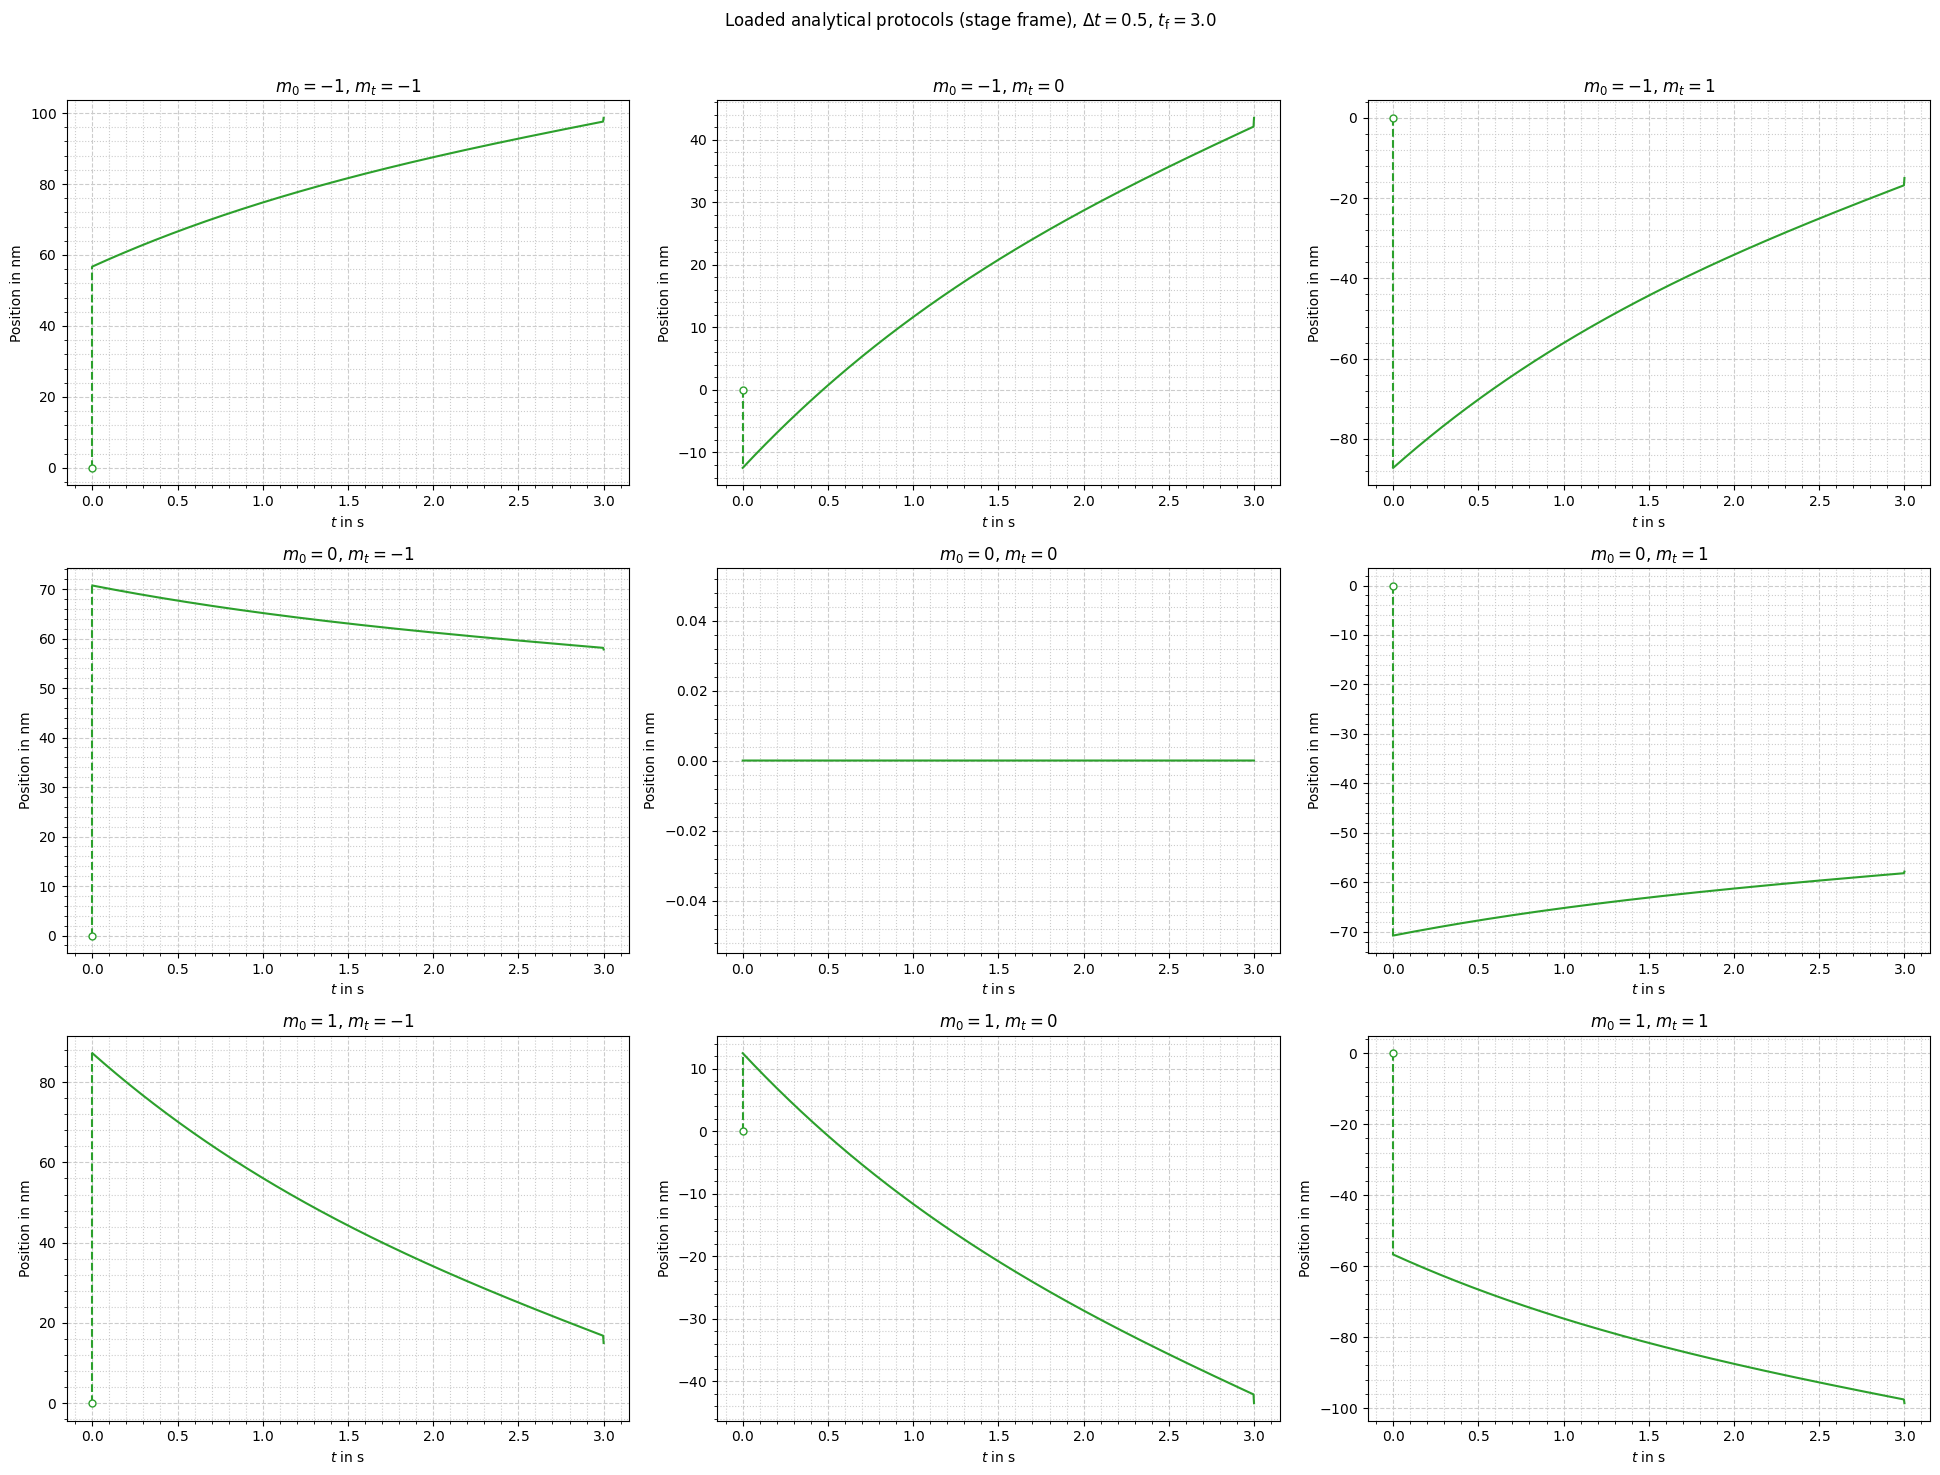

Loaded 3/3 states: [(-1, -1), (0, 0), (1, 1)]


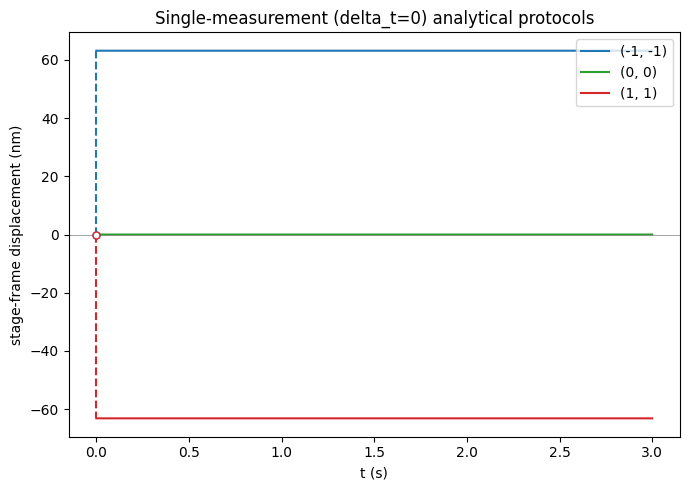

In [56]:
from analytical_protocols import load_analytical_protocols
from protocols_2ch import STATE_MENU
import os

ANALYTICAL_SAVE_DIR = os.path.join(BATCH_SAVEPATH, "analytical_protocols_used")   # this batch's own copy, not the shared solver output folder - see the parameters cell after 3b
ANALYTICAL_T2  = DELTA_T_S      # from the parameters cell above - must match t_second_measurement the files were generated with
ANALYTICAL_TF  = PROTOCOL_DT_S  # must match t_protocol_end the files were generated with

# ao was constructed with n_samples=int(PROTOCOL_DT_S * AO_RATE) (cell 9) -
# load_analytical_protocols resamples every state onto int(ANALYTICAL_TF *
# AO_RATE) samples, so these two must agree or split_channels() hands
# ao.load() a wrongly-sized array. A FINITE AO task silently truncates a
# too-long waveform rather than erroring (see hw_two_channel_test.py's
# notes), so this is worth catching loudly instead.
assert ANALYTICAL_TF == PROTOCOL_DT_S, (
    f"ANALYTICAL_TF ({ANALYTICAL_TF}) must equal PROTOCOL_DT_S "
    f"({PROTOCOL_DT_S}) - ao was built for the latter."
)

analytical_protocols = load_analytical_protocols(
    ANALYTICAL_SAVE_DIR, ANALYTICAL_T2, ANALYTICAL_TF, ao_rate=AO_RATE,
)
print(f"Loaded {len(analytical_protocols)}/9 states: {sorted(analytical_protocols)}")

print("Key -> state:")
for key, state in STATE_MENU.items():
    print(f"  {key}: {state}" + ("  (loaded)" if state in analytical_protocols else "  (NOT loaded)"))

# 3x3 grid, one subplot per (m_0, m_t) combination - same layout/style as
# analytical_optimal_protocol_computation's own
# visualization.py::plot_optimal_trajectories_grid(n_outcomes=3), so this
# is directly comparable to those reference plots. Only one line per panel
# here (the stage-frame command actually sent to ao0/ao1, after the
# trap->stage sign negation) rather than X/Xb/lambda, since that's all
# load_analytical_protocols() carries forward.
from matplotlib.ticker import AutoMinorLocator


def _plot_lambda_jump(ax, value0, color):
    """
    Mirrors visualization.py::_plot_lambda_jump - the trap (and so, after
    negation, the stage) sits at rest (0) right up to t=0, then jumps to
    the first commanded sample: a dashed vertical segment from (0, 0) to
    (0, value0), plus a small open circle marking the pre-jump rest point.
    No-op when the first sample already is 0 (e.g. the (0,0) no-op state).
    """
    if value0 == 0:
        return
    ax.plot([0, 0], [0, value0], color=color, linestyle="--", lw=1.5)
    ax.plot(0, 0, marker="o", ms=5, mfc="white", mec=color, zorder=5)


t_ao_plot = np.linspace(0.0, ANALYTICAL_TF, int(ANALYTICAL_TF * AO_RATE))
labels = [-1, 0, 1]
combinations = [(m_0, m_t) for m_0 in labels for m_t in labels]

fig = plt.figure(figsize=(6.5 * 3, 5 * 3))
for index, state in enumerate(combinations):
    ax = fig.add_subplot(3, 3, index + 1)
    ax.grid(which='major', color='#CCCCCC', linestyle='--')
    ax.grid(which='minor', color='#CCCCCC', linestyle=':')
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 3), useMathText=True)
    ax.set_xlabel("$t$ in s")
    ax.set_ylabel("Position in nm")
    ax.set_title(f"$m_0={state[0]}$, $m_t={state[1]}$")

    if state not in analytical_protocols:
        ax.text(0.5, 0.5, "no data", ha='center', va='center', transform=ax.transAxes)
        continue

    wave = analytical_protocols[state]
    line, = ax.plot(t_ao_plot, wave, color="tab:green")
    _plot_lambda_jump(ax, wave[0], line.get_color())

fig.suptitle(
    f"Loaded analytical protocols (stage frame), "
    f"$\\Delta t={ANALYTICAL_T2}$, $t_{{\\mathrm{{f}}}}={ANALYTICAL_TF}$"
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Single-measurement (delta_t=0) protocols - a separate, optional protocol
# set (not "this batch's" data - only relevant for a deliberate
# single-measurement session), so this one load deliberately reads from
# the shared solver output folder, not ANALYTICAL_SAVE_DIR above (the
# batch-specific copy only has the t2=DELTA_T_S files, not t2=0's).
# Only the diagonal states are ever meaningful (see SINGLE_MEASUREMENT_STATES's
# docstring in analytical_protocols.py) - decode_state_pair(x, x, xth_nm) can
# never produce an off-diagonal state, so real_states=SINGLE_MEASUREMENT_STATES
# avoids a spurious "missing" warning about the 6 states that were never
# expected to have files at all.
from analytical_protocols import SINGLE_MEASUREMENT_STATES

ANALYTICAL_SAVE_DIR_SHARED = r"analytical_optimal_protocol_computation/parameters/optimal_protocols_multiple_measurement"
analytical_protocols_single = load_analytical_protocols(
    ANALYTICAL_SAVE_DIR_SHARED, t_second_measurement=0, t_protocol_end=PROTOCOL_DT_S, ao_rate=AO_RATE,
    real_states=SINGLE_MEASUREMENT_STATES,
)
print(f"Loaded {len(analytical_protocols_single)}/3 states: {sorted(analytical_protocols_single)}")

fig, ax = plt.subplots(figsize=(7, 5))
for state in sorted(analytical_protocols_single):
    wave = analytical_protocols_single[state]
    line, = ax.plot(t_ao_plot, wave, label=str(state))
    _plot_lambda_jump(ax, wave[0], line.get_color())
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("t (s)")
ax.set_ylabel("stage-frame displacement (nm)")
ax.set_title("Single-measurement (delta_t=0) analytical protocols")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Run the real engine

Once steps 4-5 give you confidence, drop `active_states` entirely (full 9-state engine) — either a single session, or `run_batch_2ch` for N consecutive experiments with per-experiment parameters (camera/DAQ stay open the whole time, `ao1` carries continuously between experiments).

In [ ]:

# N consecutive experiments, e.g. matching pExp.xm=[...]/pExp.tau=[...]:
#
# run_batch_2ch() is a genuinely blocking, sequential loop — each
# run_session_2ch() call runs to completion (frame loop finished, AI
# stopped, saved) before the next experiment's params are even built.

ensure_stage_at(ao, V_CENTER, speed_nm_per_s=20.0, settle_s=1200.0,
                camera=Cam, live_preview=True,
                aom_gen=aom_gen, aom_transit_v=AOM_EXPERIMENT_V, aom_experiment_v=AOM_EXPERIMENT_V)
T_WAIT_S = 0 
FIRE_00_PROB = 1.0 / 100.0   # unbiased Bernoulli draw each time (0,0) is decoded
                             # - fires its flat/zero protocol roughly 1-in-100
                             # times, for null-work stats without spending too
                             # much time on it
base_kwargs = dict(
    fps=100.0, exposure_us=exposure_us,
    x_center_nm=x_center_nm, y_center_nm=y_center_nm,
    protocol_dt_s=PROTOCOL_DT_S, T_relax_s=T_WAIT_S, ai_rate=AI_RATE, ao_rate=AO_RATE,
    print_every=50, print_no_fire=False, savepath=BATCH_SAVEPATH,   # from the parameters cell after 3b
    fire_00_prob=FIRE_00_PROB,
)
# delta_t_s=ANALYTICAL_T2 (== DELTA_T_S, the parameters cell after 3b - not
# a separate hardcoded literal) - this is the whole point of that cell:
# whatever t_second_measurement the loaded analytical_protocols was
# actually generated for (section 3c) is exactly what this real session
# times its two decisions apart by, so the two can never silently drift
# out of sync (they did before this fix - this cell used to hardcode
# delta_t_s=0 while analytical_protocols was loaded for
# ANALYTICAL_T2=0.5, firing two-measurement-optimized protocols in a
# single-measurement-timed session). xth_nm (from 3b) is likewise the
# threshold that same analytical_protocols/ANALYTICAL_X_THRESH_SIGMA_MULT
# was built for - not xth_nm_single/analytical_protocols_single, which are
# 3c's separate t_second_measurement=0 pair, only for a deliberate
# single-measurement run (swap every one of xth_nm/ANALYTICAL_T2/
# analytical_protocols below for its _single counterpart together, never
# just one of them).
experiment_overrides = [
    dict(xth_nm=xth_nm, delta_t_s=ANALYTICAL_T2, trecord_s=7200.0)
    for _ in range(4)
]
batch_results = run_batch_2ch(base_kwargs, experiment_overrides, ao, ai, Cam, funcgen,
                              ao1_start_v = V_CENTER, settle_s_between = 1200.0, reset_speed_nm_per_s = 20.0,
                              aom_gen=aom_gen, aom_transit_v=AOM_EXPERIMENT_V, aom_experiment_v=AOM_EXPERIMENT_V,
                              protocols=analytical_protocols)



Stage already at 4.980 V (target 5.000 V) - no move needed.

 Experiment 1/2
Session (2ch dry run): 120.0 min  (720000 frames at 100.0 fps)
delta_t=0.5s (50 frames)  protocol_dt=3.0s (300 frames)  T_relax=0s (1 frames)  -> post-fire gap = protocol_dt+T_relax = 3.0s  xth=44.262926656407124 nm

[Camera] Hardware trigger (Line2, rising edge)
[Camera] Started
Session running - Ctrl+C to stop early

  t= 239.49s  frame=  23949  state=(-1, 0)     x_prev=  -71.6  x_curr=  +17.3  -> ao1 offset 5.0240 V
  t= 464.98s  frame=  46499  state=(1, 0)      x_prev=  +78.2  x_curr=  +15.4  -> ao1 offset 5.0440 V
  t= 702.48s  frame=  70249  state=(1, 0)      x_prev=  +49.4  x_curr=  +14.8  -> ao1 offset 4.8923 V
  t= 939.97s  frame=  93999  state=(-1, -1)    x_prev=  -99.3  x_curr=  -96.2  -> ao1 offset 4.9971 V
  t=1176.46s  frame= 117649  state=(0, 1)      x_prev=  -25.5  x_curr=  +53.5  -> ao1 offset 4.8624 V
  t=1413.96s  frame= 141399  state=(1, 0)      x_prev=  +70.0  x_curr=  +39.7  -> ao1 offset

In [59]:
ensure_stage_at(ao, V_CENTER, speed_nm_per_s=20.0, camera=Cam, live_preview=True, settle_s = 300,
                aom_gen=aom_gen, aom_transit_v=AOM_EXPERIMENT_V, aom_experiment_v=AOM_EXPERIMENT_V)


Setting AOM to 1.000 V for the transit ...
[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Preview started (particle_cross=True)
Stage at 2.560 V, ramping to 5.000 V at 20.0 nm/s ...
Arrived at 5.000 V.
Waiting 10s, then setting AOM to 1.000 V ...
Settling for 300s ...
  ... 270s remaining
  ... 240s remaining
  ... 210s remaining
  ... 180s remaining
  ... 150s remaining
  ... 120s remaining
  ... 90s remaining
  ... 60s remaining
  ... 30s remaining
  ... 0s remaining
Settle complete.
[Camera] Preview stopped


5.0

In [62]:
import importlib
import analysis
import helper
importlib.reload(analysis)
from analysis import (
    compute_potential, plot_potential,
    extract_protocol_events, lambda_trap_nm_for_state,
    compute_cumulative_work_kT, plot_x_lambda_grid, plot_work_grid, export_for_matlab,
    discover_session_files, load_session_files,
    extract_protocol_events_from_folder, extract_protocol_events_from_folders,
    extract_protocol_stage_events_from_folder, plot_stage_vs_protocol_grid,
    compute_work_split_kT, plot_trap_relative_grid, plot_work_split_grid,
    compute_trigger_energy_reference_kT,
    compute_experimental_probabilities, compute_weighted_mean_work_kT,
    compute_weighted_average_kT,
)
importlib.reload(helper)
from helper import *
# Reloaded under a different name on purpose - "analytical_protocols" is
# also the variable 3c (cell 5fa7d7bd) uses for the loaded protocol dict;
# `import analytical_protocols` here would rebind that name to the MODULE
# and silently clobber the dict right before 4b needs it (exactly what
# broke - lambda_trap_nm_for_state got the module, not the dict, and threw
# "'module' object is not subscriptable"). This reloads the module's code
# (so newly-added functions like load_predicted_work_J are visible) without
# touching the notebook's own `analytical_protocols` variable at all.
import analytical_protocols as _analytical_protocols_module
importlib.reload(_analytical_protocols_module)


<module 'analytical_protocols' from 'd:\\Optimal_Info_Engine\\analytical_protocols.py'>

## 4b. Batch-folder analysis: pooled statistics across all N experiments

Once section 4's batch has actually run and saved into its batch folder (`base_kwargs["savepath"]`, e.g. `r"D:\data\batch01"`), this pools every experiment's real fired events per state into one combined matrix via `extract_protocol_events_from_folder` — e.g. 2 experiments' worth of state `(1,1)` events become a single `(n_total_events, protocol_frames)` array, instead of having to look at each experiment's file separately.

Three diagnostics/results, all from the batch folder plus the currently-loaded `analytical_protocols`:
1. `plot_stage_vs_protocol_grid` — measured Stage-channel readback (ground truth) vs. the loaded protocol's stage-frame curve, no camera data involved. A mismatch flags a wrong/stale protocol loaded for this batch.
2. `plot_trap_relative_grid` — trap-relative `X = x_cam + lambda` (avoids the reference-frame plunge raw `x_cam` shows right at the jump), `lambda`'s own jump drawn as a dashed marker.
3. `compute_work_split_kT`/`plot_work_split_grid` — cumulative work with the jump's own contribution reported and plotted separately from the smooth part that follows it, plus two dashed reference lines per state: the analytical solver's own predicted mean work (`load_predicted_work_J`, gray dashed) and `-0.5*kappa*<x_trigger>^2` (`compute_trigger_energy_reference_kT`, brown dotted) - the naive energy available at the trigger instant, computed straight from the real data, no solver dependency.

Also prints, via the generic `compute_weighted_average_kT` primitive (`compute_weighted_mean_work_kT` is built on it), two probability-weighted overall means each for work and for `V_ij` (`trigger_reference_kT`): once against this batch's own real fire-count fractions (`compute_experimental_probabilities` - always available, `fire_00_prob`-corrected), and once against the solver's predicted `P(m_0,m_t)` (`load_predicted_probabilities` - only available once `run_single_parameter_point_cli.py` has been run with `--save_dir=ANALYTICAL_SAVE_DIR` since it started saving `predicted_probabilities.json`).

(1, 1): 292 real fired events pooled across the batch (300 samples/event)
(1, 0): 609 real fired events pooled across the batch (300 samples/event)
(0, 1): 666 real fired events pooled across the batch (300 samples/event)
(-1, 1): 40 real fired events pooled across the batch (300 samples/event)
(-1, -1): 245 real fired events pooled across the batch (300 samples/event)
(-1, 0): 556 real fired events pooled across the batch (300 samples/event)
(0, -1): 579 real fired events pooled across the batch (300 samples/event)
(1, -1): 29 real fired events pooled across the batch (300 samples/event)
(0, 0): 37 real fired events pooled across the batch (300 samples/event)
(1, 1): mean jump work = -1.13 kT   mean final work = -1.12 kT   (n=292)
(1, 0): mean jump work = +0.10 kT   mean final work = -0.15 kT   (n=609)
(0, 1): mean jump work = -0.98 kT   mean final work = -1.03 kT   (n=666)
(-1, 1): mean jump work = -0.71 kT   mean final work = -1.38 kT   (n=40)
(-1, -1): mean jump work = -1.08 kT   m

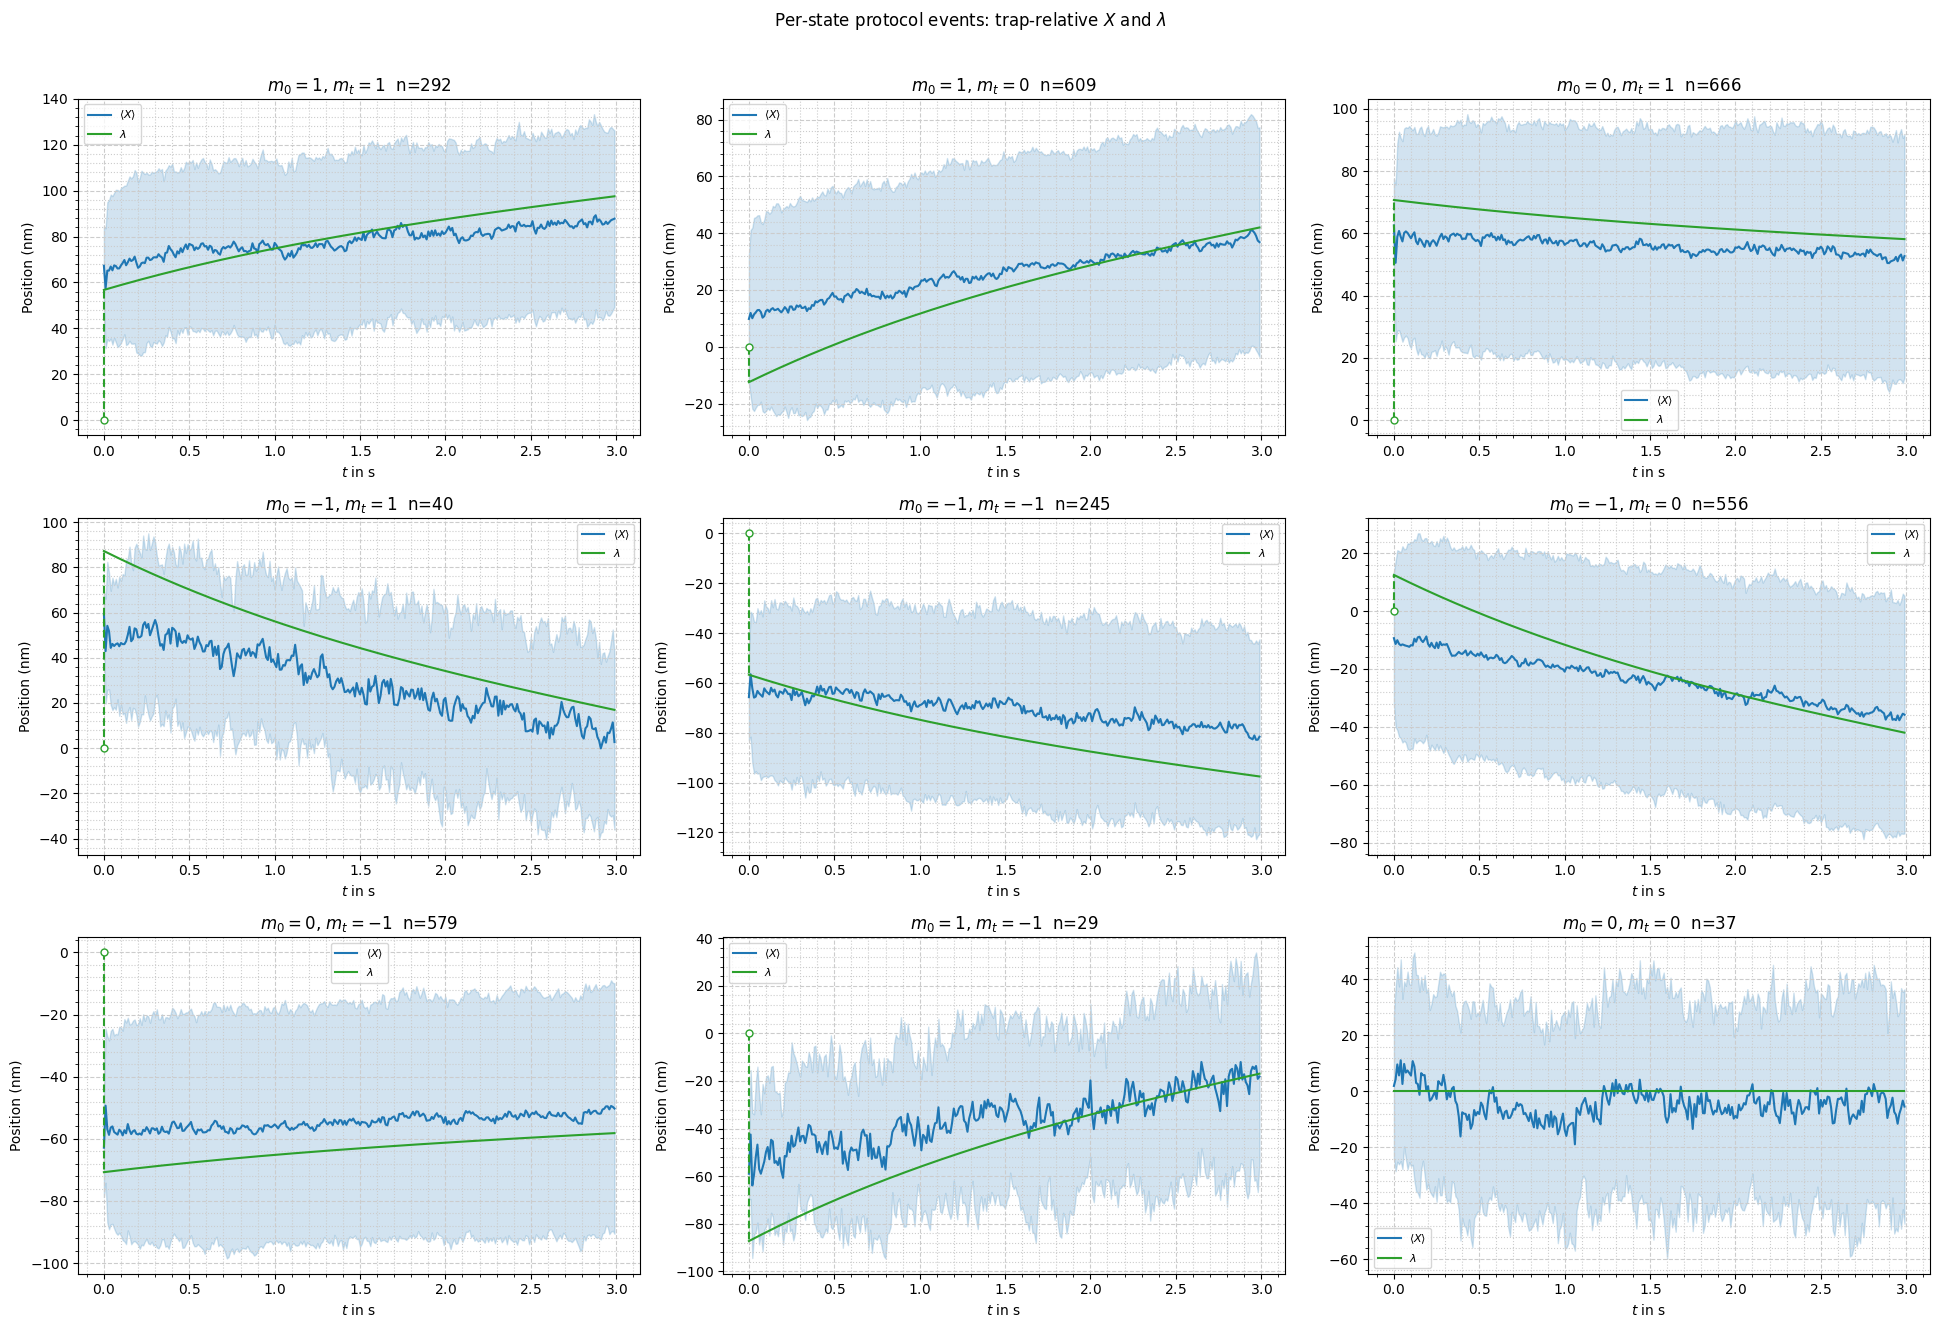

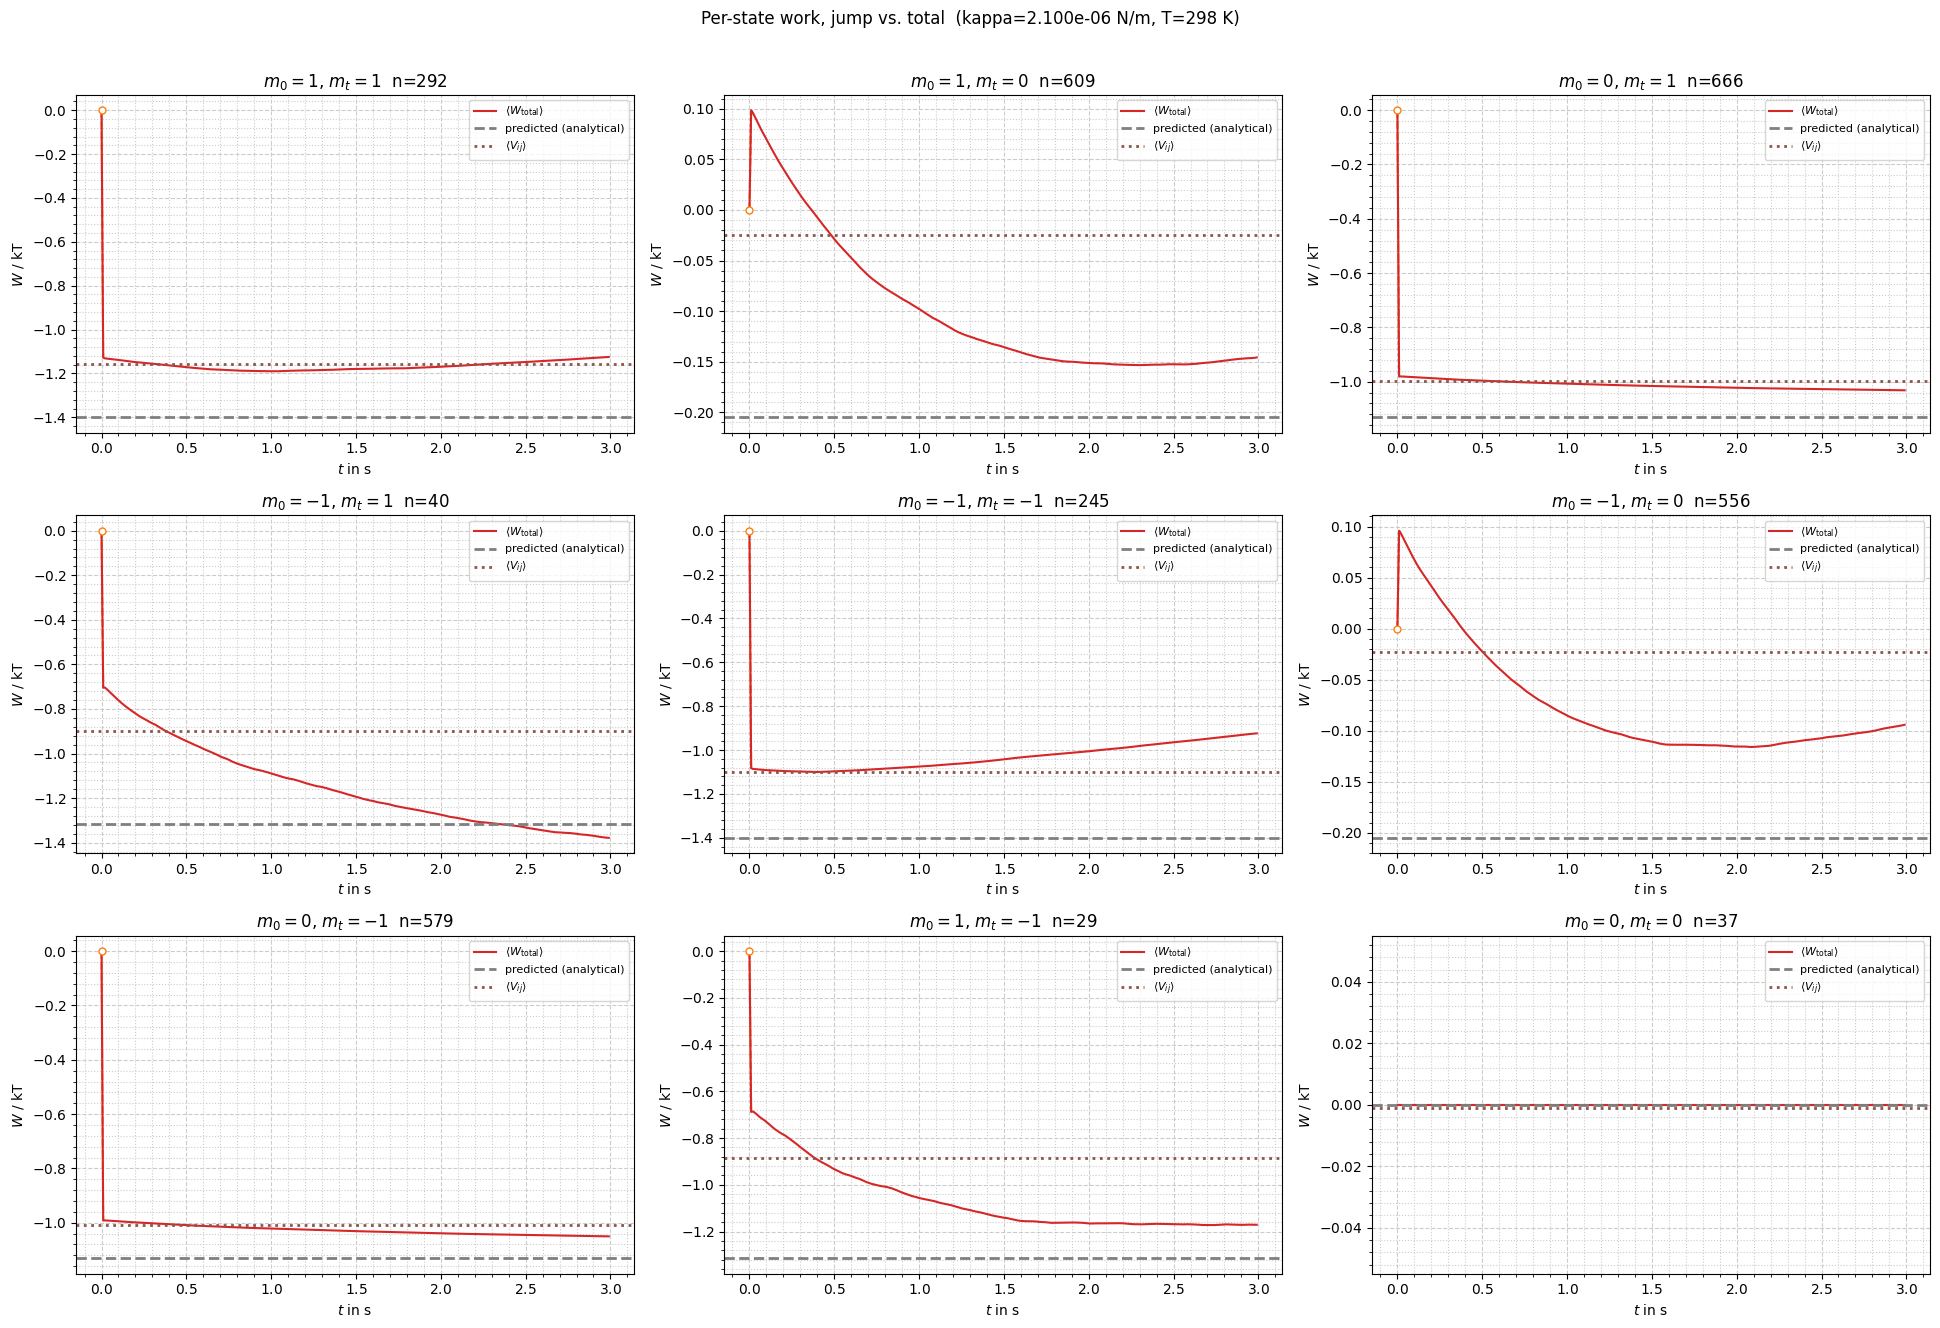

Saved: D:\Data\Aug_26\26-08_Testing_Full_Engine\batch04_events_work.mat

Experimental-probability-weighted mean work: -0.310 kT
Experimental-probability-weighted mean V:    -0.290 kT
Analytical-probability-weighted mean work:   -0.358 kT
Analytical-probability-weighted mean V:      -0.333 kT


In [63]:
BATCH_FOLDER = BATCH_SAVEPATH   # from the parameters cell after 3b - same folder section 4's run_batch_2ch just saved into

batch_events = extract_protocol_events_from_folder(BATCH_FOLDER)
for state, ev in batch_events.items():
    print(f"{state}: {ev['x_nm'].shape[0]} real fired events pooled across the batch "
          f"({ev['x_nm'].shape[1]} samples/event)")

# The real fire_00_prob this batch was actually recorded with, read from
# its own saved session params - NOT section 4's FIRE_00_PROB, which only
# exists in this kernel if section 4's (hardware-driving) cell was just
# run. Analyzing an already-recorded batch shouldn't require re-running
# that cell (it would try to fire a new real experiment), so this reads it
# straight from disk instead - every session in a batch shares one
# fire_00_prob (run_batch_2ch passes base_kwargs through unchanged), so
# the first session's saved value is enough.
fire_00_prob = load_session_files(discover_session_files(BATCH_FOLDER)[0])["params"].fire_00_prob

batch_lambdas = {
    state: lambda_trap_nm_for_state(state, batch_events[state]["t_s"], analytical_protocols,
                                    PROTOCOL_DT_S, AO_RATE)
    for state in batch_events
}

# compute_work_split_kT() reports the jump's own work separately from the
# smooth part that follows it (plot_work_split_grid draws the jump as a
# dashed step) - see its docstring for why it deliberately uses a
# different landing-frame convention than plot_trap_relative_grid below.
batch_W_jump_kT, batch_W_total_kT = {}, {}
for state in batch_events:
    W_jump, W_total = compute_work_split_kT(batch_events[state]["x_nm"], batch_lambdas[state],
                                            ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K)
    batch_W_jump_kT[state] = W_jump
    batch_W_total_kT[state] = W_total

for state in batch_events:
    if batch_events[state]["x_nm"].shape[0]:
        print(f"{state}: mean jump work = {batch_W_jump_kT[state].mean():+.2f} kT   "
              f"mean final work = {batch_W_total_kT[state][:, -1].mean():+.2f} kT   "
              f"(n={batch_events[state]['x_nm'].shape[0]})")

# Two reference lines for the work plot below:
#  - predicted_work_kT: the analytical solver's own predicted mean work per
#    state (load_predicted_work_J(), same save_dir/t2/tf as analytical_protocols
#    above - must point at the same parameter point) - "what the optimal
#    protocol was designed to extract".
#  - trigger_reference_kT: -0.5*kappa*<x_trigger>^2/kT, computed straight
#    from batch_events (no solver dependency) - "what was naively available
#    at the trigger instant" (e.g. for (1,1), the mean pre-fire x that was
#    > xth_nm and so decoded/fired this state in the first place).
from analytical_protocols import load_predicted_work_J

predicted_work_J = load_predicted_work_J(ANALYTICAL_SAVE_DIR, ANALYTICAL_T2, ANALYTICAL_TF)
kT_J = K_BOLTZMANN_J_PER_K * ANALYTICAL_T_K
predicted_work_kT = {state: predicted_work_J[state] / kT_J for state in predicted_work_J}

trigger_reference_kT = compute_trigger_energy_reference_kT(batch_events, ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K)

plot_trap_relative_grid(batch_events, batch_lambdas)
plot_work_split_grid(batch_events, batch_W_jump_kT, batch_W_total_kT, ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K,
                     predicted_work_kT=predicted_work_kT, trigger_reference_kT=trigger_reference_kT)

export_for_matlab(f"{BATCH_FOLDER}_events_work.mat", batch_events, batch_lambdas, batch_W_total_kT,
                  ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K, PROTOCOL_DT_S)

# Probability-weighted mean work across all states, two ways:
#  1. sum(analytical_prob_ij * mean(w_ij)) - the solver's own predicted
#     P(m_0,m_t), which only exists on disk if run_single_parameter_point_cli.py
#     has been (re-)run since it started saving predicted_probabilities.json -
#     re-run the exact command printed by the parameters cell after 3b if
#     this raises FileNotFoundError.
#  2. sum(exp_prob_ij * mean(w_ij)) - this batch's own real fire-count
#     fractions (compute_experimental_probabilities()), no solver dependency.
#     fire_00_prob (this batch's own saved value, above) corrects (0,0)'s
#     count for the fact that only a fire_00_prob fraction of real (0,0)
#     decodes ever get fired/counted (every other state fires on every
#     decode, no such gating) - without this, (0,0)'s true probability is
#     massively understated and every other state's is inflated. See
#     compute_experimental_probabilities()'s docstring.
# Both use batch_W_total_kT (this batch's measured mean work per state),
# just weighted by a different probability source - compare them to see
# whether the batch's real decode/fire rates matched the solver's prediction.
from analytical_protocols import load_predicted_probabilities

exp_prob = compute_experimental_probabilities(batch_events, fire_00_prob=fire_00_prob)
mean_work_exp_weighted_kT = compute_weighted_mean_work_kT(batch_W_total_kT, exp_prob)
print(f"\nExperimental-probability-weighted mean work: {mean_work_exp_weighted_kT:+.3f} kT")

# Average V_ij (= trigger_reference_kT, the -0.5*kappa*<x_trigger>^2/kT
# reference computed above) using the same experimental probabilities -
# compute_weighted_average_kT() is the generic weighted-average primitive
# compute_weighted_mean_work_kT() itself is built on, just applied to a
# per-state scalar (trigger_reference_kT) instead of a per-state work
# time-series.
mean_V_exp_weighted_kT = compute_weighted_average_kT(trigger_reference_kT, exp_prob)
print(f"Experimental-probability-weighted mean V:    {mean_V_exp_weighted_kT:+.3f} kT")

try:
    analytical_prob = load_predicted_probabilities(ANALYTICAL_SAVE_DIR)
    mean_work_analytical_weighted_kT = compute_weighted_mean_work_kT(batch_W_total_kT, analytical_prob)
    mean_V_analytical_weighted_kT = compute_weighted_average_kT(trigger_reference_kT, analytical_prob)
    print(f"Analytical-probability-weighted mean work:   {mean_work_analytical_weighted_kT:+.3f} kT")
    print(f"Analytical-probability-weighted mean V:      {mean_V_analytical_weighted_kT:+.3f} kT")
except FileNotFoundError as e:
    print(f"\nAnalytical-probability-weighted mean work/V: not available yet - {e}")


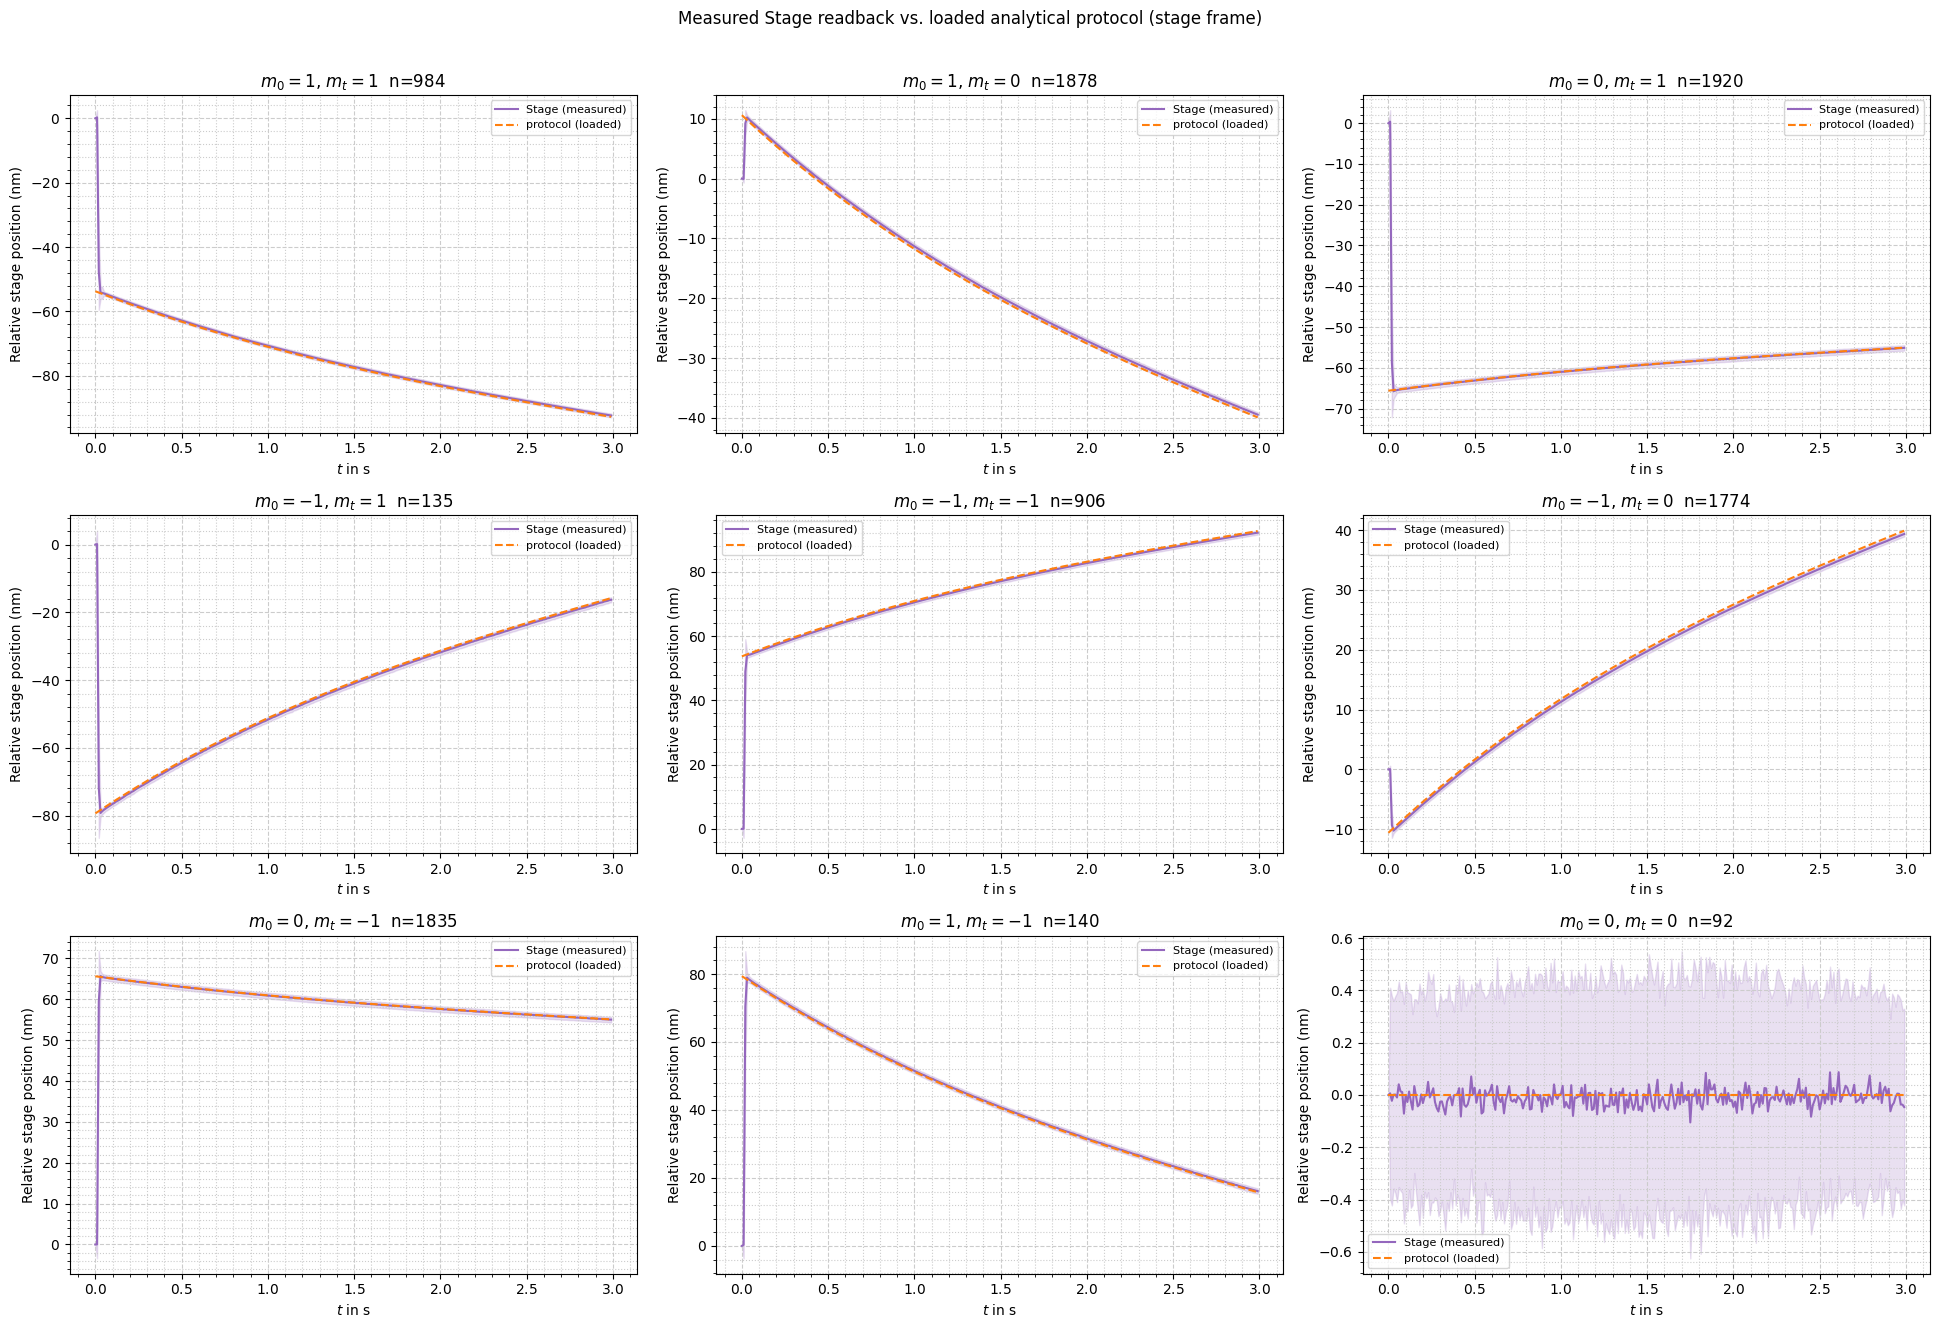

In [42]:
from analysis import extract_protocol_stage_events_from_folder, plot_stage_vs_protocol_grid

batch_stage_events = extract_protocol_stage_events_from_folder(BATCH_FOLDER)

batch_stage_protocol_nm = {
    state: -lambda_trap_nm_for_state(state, batch_stage_events[state]["t_s"], analytical_protocols,
                                     PROTOCOL_DT_S, AO_RATE)
    for state in batch_stage_events
}

plot_stage_vs_protocol_grid(batch_stage_events, batch_stage_protocol_nm)


## 5. Confirm the particle is still there

In [44]:
preview_particle(Cam, fps=100.0)


[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Preview started (particle_cross=True)
[Camera] Preview stopped


## 6. Shutdown (optional — only when you're actually powering down)

Ramp `ao1` slowly back to 0V rather than stepping it (a bare voltage step risks losing the particle), then close everything. Left commented out — your call when to actually run it, and it's independent of everything above.

In [46]:
aom_gen.set_dc_level(AOM_TRANSIT_V)   # strong trap before the shutdown ramp, same as any other transit

current_v = read_stage_voltage()
ao.ramp_ao1(current_v, 0.0, speed_nm_per_s=20.0)

ao.close()
ai.close()
Cam.close()
funcgen.close()
aom_gen.close()


[Camera] Preview stopped
[Camera] Stopped
[Camera] Closed
